In [51]:
import os, gc
import pickle
import gzip
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from memory_profiler import memory_usage
import sys
sys.path.append('/home/anas/Desktop/Simulations/Training_NLO/nonlinear_oscillator_network/Utils')

from NN_utils import *
from kneed import KneeLocator
import scipy
#from torchvision import datasets, transforms
#from torchsummary import summary
import time
from data_processing_utils import * 
%config InlineBackend.figure_format = 'svg'
#mpl.rcParams['figure.dpi'] = 150  
#mpl.rcParams['savefig.dpi'] = 150
#mpl.rcParams['figure.figsize'] = (4,2)  

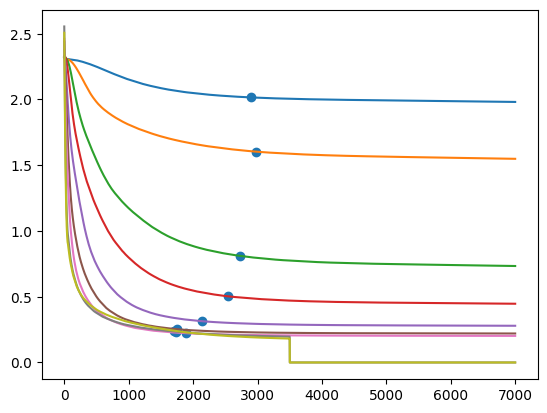

In [2]:
N_neurons_vec_PEPG = [5, 10, 20 ,30, 50, 75, 100,150,180]

with gzip.open('paramscan_PNN_PEPG_MNIST_run1.pkl.gz', 'rb') as f:
    resultsPEPG1 = pickle.load(f)

with gzip.open('paramscan_PNN_PEPG_MNIST_run2.pkl.gz', 'rb') as f:
    resultsPEPG2 = pickle.load(f)

with gzip.open('paramscan_PNN_PEPG_MNIST_run3.pkl.gz', 'rb') as f:
    resultsPEPG3 = pickle.load(f)

dicts_list = [resultsPEPG1, resultsPEPG2,resultsPEPG3]  # list of runs

# Average them with our new shiny function lol
avg_results_PEPG = average_data_dicts(dicts_list)

#locate convergence knee to determine convergence
knee_idx_PEPG,loss_PEPG_conv,acc_PEPG_conv = locate_curve_knee(avg_results_PEPG,N_neurons_vec_PEPG,idx_start = 500,plot_bool=True)

In [3]:
avg_results_PEPG[-1]["time"]/3600/24

np.float64(11.124302897964732)

slope 1.53884518937569
intercept -4.225629959704764
NUms params : [4045, 8180, 16750, 25720, 44860, 71035, 99710, 164560, 208270]


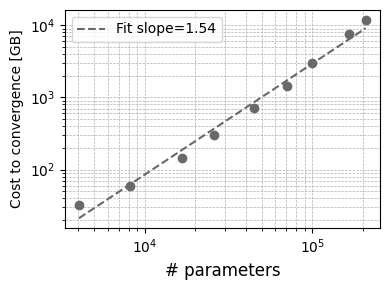

In [5]:
#process memory cost for the algorithm using the knee idx and the memory budget per epoch

PEPG_mem_perepoch = np.array([11.2,19.76,53.82,117.27,330.8,816.62,1603.96,4347.31,6951.7])/1000 #with peak mem CUDA torch profiler
#PEPG_mem_perepoch = np.array([1.945, 7.866, 32.592, 76.537, 231.036, 578.829, 1141.121, 3103.629, 4967.196])/1000 #with peak mem theory

a_PEPG,b_PEPG,N_dim_vec_PEPG,PEPG_cost_to_conv = process_cost_to_conv(avg_results_PEPG,knee_idx_PEPG,PEPG_mem_perepoch)

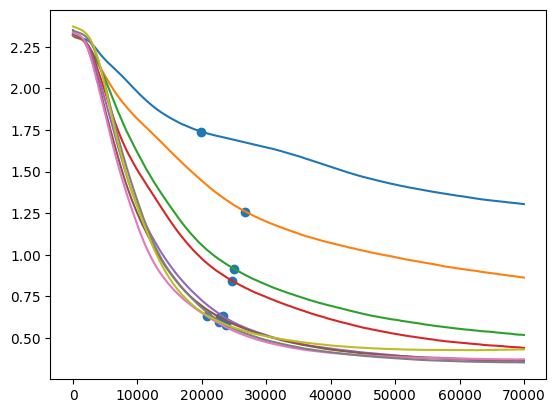

In [6]:
N_neurons_vec_SPSA = [5, 10, 20 ,30, 50, 75, 100,150,250]

with gzip.open('paramscan_PNN_SPSA_MNIST_run1.pkl.gz', 'rb') as f:
    results_SPSA1 = pickle.load(f)

with gzip.open('paramscan_PNN_SPSA_MNIST_run2.pkl.gz', 'rb') as f:
    results_SPSA2 = pickle.load(f)

with gzip.open('paramscan_PNN_SPSA_MNIST_run3.pkl.gz', 'rb') as f:
    results_SPSA3 = pickle.load(f)

dicts_list = [results_SPSA1, results_SPSA2,results_SPSA3]  # list of runs


# Average them with our new shiny function lol
avg_results_SPSA = average_data_dicts(dicts_list)

#locate convergence knee to determine convergence
knee_idx_SPSA,loss_SPSA_conv,acc_SPSA_conv = locate_curve_knee(avg_results_SPSA,N_neurons_vec_SPSA,idx_start = 3000,plot_bool=True)



slope 0.9935544389693869
intercept -2.825744814305399
NUms params : [4045, 8180, 16750, 25720, 44860, 71035, 99710, 164560, 324260]


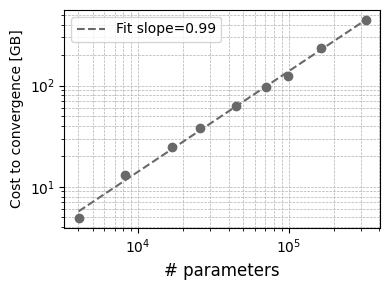

In [ ]:
#process memory cost for the algorithm using the knee idx and the memory budget per epoch

SPSA_mem_perepoch = np.array([0.246, 0.492, 1, 1.54,2.7,4.26,5.98,9.88,19.67])/1000 # CUDA torch Peak

a_SPSA,b_SPSA,N_dim_vec_SPSA,SPSA_cost_to_conv = process_cost_to_conv(avg_results_SPSA,knee_idx_SPSA,SPSA_mem_perepoch)



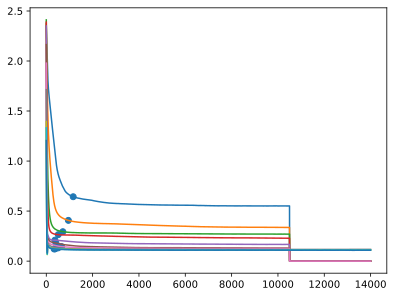

In [60]:
N_neurons_vec_BP = [5, 10, 20 ,30, 50, 75, 100,150,250,300,400]

with gzip.open('paramscan_PNN_BP_MNIST_run1.pkl.gz', 'rb') as f:
    results_BP1 = pickle.load(f)

with gzip.open('paramscan_PNN_BP_MNIST_run2.pkl.gz', 'rb') as f:
    results_BP2 = pickle.load(f)

with gzip.open('paramscan_PNN_BP_MNIST_run3.pkl.gz', 'rb') as f:
    results_BP3 = pickle.load(f)


#with open('BP_batch_scan/paramscan_batch10_lr0p0001_PNN_BP_MNIST.pkl', 'rb') as f:
#    results_BP_lasthope = pickle.load(f)

dicts_list = [results_BP1, results_BP2,results_BP3]  # list of runs
#dicts_list = [results_BP_lasthope]  # list of runs



# Average them with our new shiny function lol
avg_results_BP = average_data_dicts(dicts_list)


#locate convergence knee to determine convergence
knee_idx_BP,loss_BP_conv,acc_BP_conv = locate_curve_knee(avg_results_BP,N_neurons_vec_BP,idx_start = 100,idx_run=-1,plot_bool=True)

1708


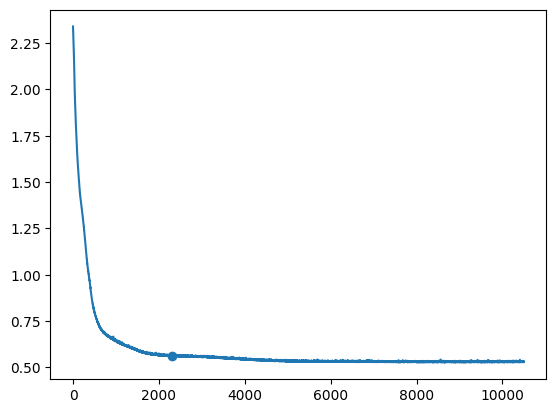

In [44]:

smooth_loss1 = scipy.signal.savgol_filter(results_BP1[0]['test_loss'],window_length=200,polyorder=3)

plt.plot(results_BP1[0]['test_loss'])
#plt.plot(results_BP2[0]['test_loss'])
#plt.plot(results_BP3[0]['test_loss'])

idx_start = 600
kneedle = KneeLocator(
        np.arange(idx_start,len(smooth_loss1)), smooth_loss1[idx_start:],
        S=1.0,                     # sensitivity (larger -> fewer knees)
        curve="convex",            # try "concave" if your curve bends the other way
        direction="decreasing",    # loss goes down with epochs
        online=False
    )
print(kneedle.knee)
plt.scatter(kneedle.knee + idx_start,results_BP1[0]['test_loss'][kneedle.knee+idx_start])

In [61]:
knee_idx_BP

array([1161,  953,  715,  516,  372,  413,  660,  513,  389,  374,  338])

slope -0.11574619892062966
intercept 1.701942989853384
NUms params : [4045, 8180, 16750, 25720, 44860, 71035, 99710, 164560, 324260, 419110, 638810]


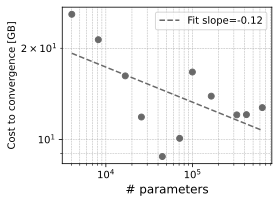

In [62]:
#process memory cost for the algorithm using the knee idx and the memory budget per epoch

BP_mem_perepoch = np.array([6.371, 6.647, 7.203, 7.764, 8.898, 10.342, 11.815, 14.846, 21.251, 24.625, 31.717])/1000 #peak total theory batch = 1000
BP_mem_perepoch = np.array([22.3,22.4,22.68,22.99,23.62,24.43,25.3,27.1,31,32.3, 37.7])/1000 #peak total batch = 1000 torch cuda

#BP_mem_perepoch = np.array([0.11, 0.159, 0.262, 0.369, 0.597, 0.908, 1.248, 2.013, 3.886, 4.995, 7.555])/1000 #peak total theory batch = 10
#BP_mem_perepoch = np.array([0.019, 0.035, 0.07, 0.106, 0.182, 0.286, 0.401, 0.66, 1.299, 1.679, 2.557])/1000 #peak total batch = 10 torch cuda

#BP_mem_perepoch = np.array([18.19,18.27,18.44,18.62,19,19.52,20.1,21.4,24.59,26.49,31.05])/1000 #peak total batch = 1 torch cuda
knee_idx_BP
a_BP,b_BP,N_dim_vec_BP,BP_cost_to_conv = process_cost_to_conv(avg_results_BP,knee_idx_BP,BP_mem_perepoch)

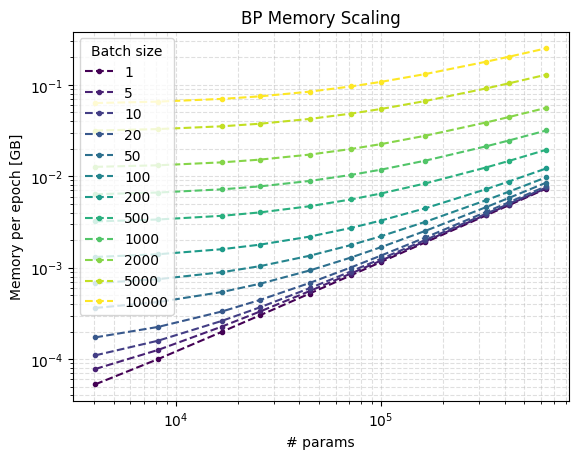

In [8]:
BP_mem_perepoch_1 = np.array([0.053, 0.1, 0.199, 0.302, 0.522, 0.822, 1.152, 1.896, 3.728, 4.816, 7.335])/1000 #peak total theory batch = 1
BP_mem_perepoch_5 = np.array([0.078, 0.126, 0.227, 0.332, 0.555, 0.861, 1.194, 1.948, 3.799, 4.895, 7.433])/1000
BP_mem_perepoch_10 = np.array([0.11, 0.159, 0.262, 0.369, 0.597, 0.908, 1.248, 2.013, 3.886, 4.995, 7.555])/1000 #peak total theory batch = 1
BP_mem_perepoch_20 = np.array([0.173, 0.225, 0.332, 0.444, 0.681, 1.004, 1.355, 2.142, 4.062, 5.193, 7.799])/1000 
BP_mem_perepoch_50 = np.array([0.363, 0.421, 0.542, 0.668, 0.933, 1.289, 1.675, 2.531, 4.588, 5.788, 8.531])/1000 
BP_mem_perepoch_100 = np.array([0.679, 0.749, 0.893, 1.041, 1.352, 1.766, 2.208, 3.179, 5.465, 6.779, 9.751])/1000
BP_mem_perepoch_200 = np.array([1.311, 1.404, 1.594, 1.788, 2.19, 2.719, 3.276, 4.476, 7.219, 8.762, 12.192])/1000 

BP_mem_perepoch_500 = np.array([3.209, 3.37, 3.697, 4.029, 4.706, 5.577, 6.478, 8.364, 12.481, 14.711, 19.514])/1000 
BP_mem_perepoch_1000 = np.array([6.371, 6.647, 7.203, 7.764, 8.898, 10.342, 11.815, 14.846, 21.251, 24.625, 31.717])/1000
BP_mem_perepoch_2000 = np.array([12.696, 13.201, 14.215, 15.233, 17.283, 19.871, 22.488, 27.808, 38.791, 44.454, 56.123])/1000

BP_mem_perepoch_5000 = np.array([31.67, 32.862, 35.249, 37.64, 42.437, 48.458, 54.509, 66.695, 91.411, 103.94, 129.343])/1000 
BP_mem_perepoch_10000 = np.array([63.294, 65.63, 70.306, 74.986, 84.36, 96.104, 107.876, 131.507, 179.111, 203.084, 251.375])/1000 


#  y-data arrays in a list (in the same order as plot )
BP_arrays = [
    BP_mem_perepoch_1,
    BP_mem_perepoch_5,
    BP_mem_perepoch_10,
    BP_mem_perepoch_20,
    BP_mem_perepoch_50,
    BP_mem_perepoch_100,
    BP_mem_perepoch_200,
    BP_mem_perepoch_500,
    BP_mem_perepoch_1000,
    BP_mem_perepoch_2000,
    BP_mem_perepoch_5000,
    BP_mem_perepoch_10000,
]

# The labels for the legend
labels = ["1", "5", "10", "20", "50", "100","200", "500", "1000","2000","5000","10000"]

# Build a colormap proportional to number of curves
cmap = plt.cm.viridis
colors = cmap(np.linspace(0, 1, len(BP_arrays)))

a_BP_batchsweep = []
b_BP_batchsweep = []
plt.figure()
for arr, label, color in zip(BP_arrays, labels, colors):
    plt.loglog(N_dim_vec_BP, arr, '--.', color=color, label=label)
    a_BP, b_BP = np.polyfit(np.log10(N_dim_vec_BP[-5:]), np.log10(arr[-5:]), 1)  # linear fit
    a_BP_batchsweep.append(a_BP)
    b_BP_batchsweep.append(b_BP)
    

# Legend depending on number
plt.legend(title="Batch size", fontsize=10)

plt.xlabel("# params")
plt.ylabel("Memory per epoch [GB]")
plt.title("BP Memory Scaling")
plt.grid(True, which="both", ls="--", alpha=0.4)

plt.show()


Text(0, 0.5, 'Asymptote slope')

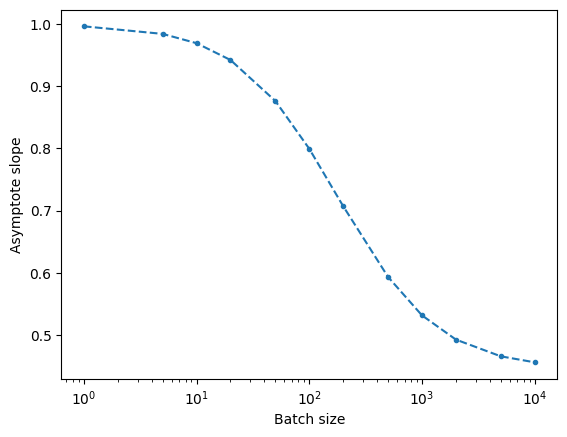

In [9]:
labels = [int(i) for i in labels]
plt.semilogx(labels,a_BP_batchsweep,'.--')
plt.xlabel("Batch size")
plt.ylabel("Asymptote slope")

slope 0.9667685953052454
intercept -4.97792393869766
NUms params : [4045, 8180, 16750, 25720, 44860, 71035, 99710, 164560, 324260, 419110, 638810]


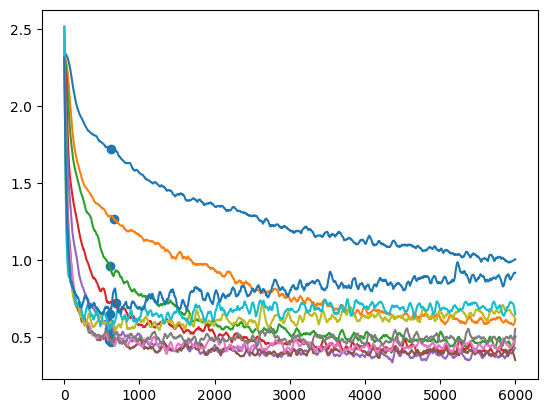

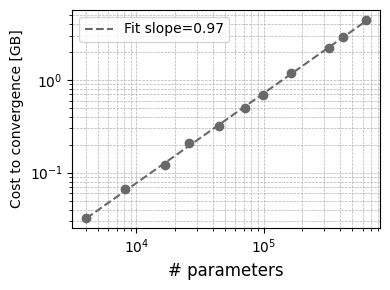

slope 0.8466552405814961
intercept -4.32867501264674
NUms params : [4045, 8180, 16750, 25720, 44860, 71035, 99710, 164560, 324260, 419110, 638810]


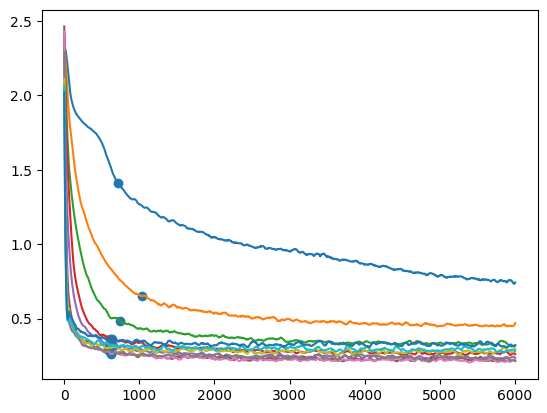

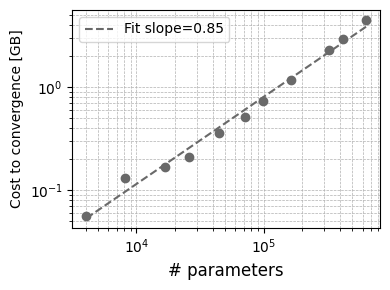

slope 0.7841766063004308
intercept -3.9759638277987848
NUms params : [4045, 8180, 16750, 25720, 44860, 71035, 99710, 164560, 324260, 419110, 638810]


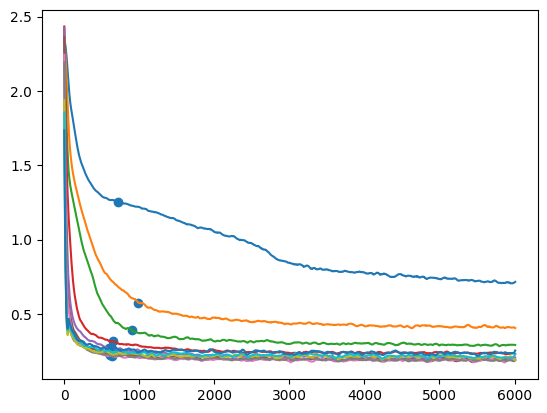

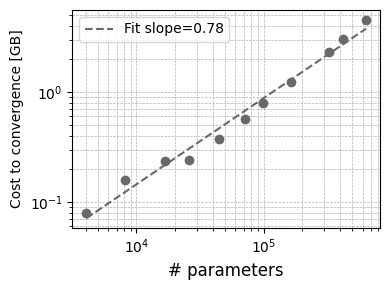

slope 0.6676547499766838
intercept -3.342374694745683
NUms params : [4045, 8180, 16750, 25720, 44860, 71035, 99710, 164560, 324260, 419110, 638810]


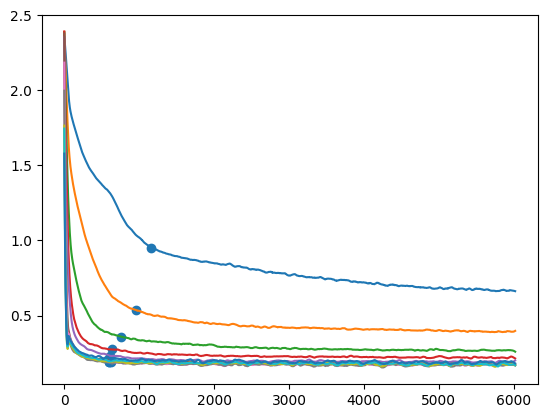

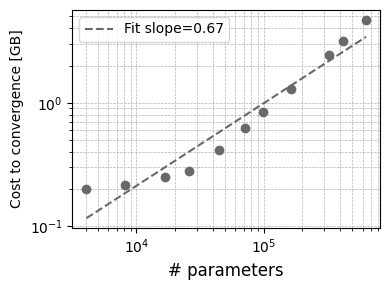

slope 0.5425706762993532
intercept -2.6081605393054414
NUms params : [4045, 8180, 16750, 25720, 44860, 71035, 99710, 164560, 324260, 419110, 638810]


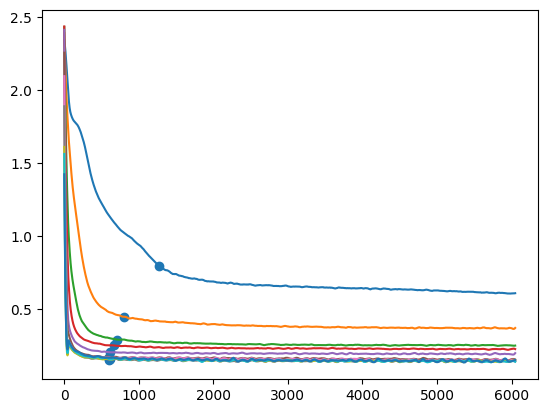

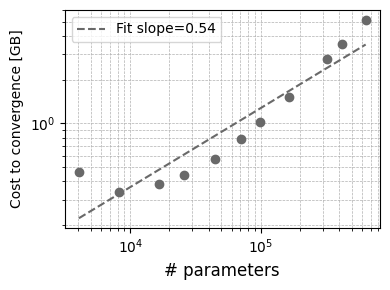

slope 0.4336726906263183
intercept -1.9305313166180234
NUms params : [4045, 8180, 16750, 25720, 44860, 71035, 99710, 164560, 324260, 419110, 638810]


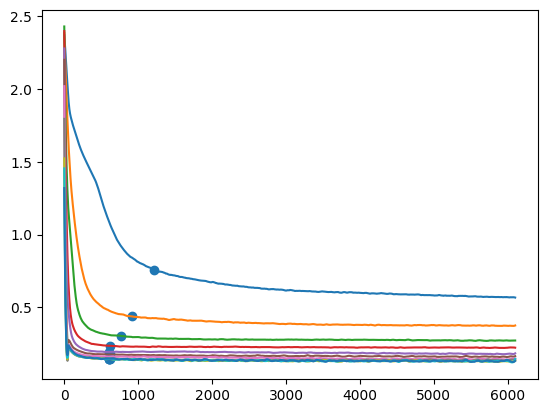

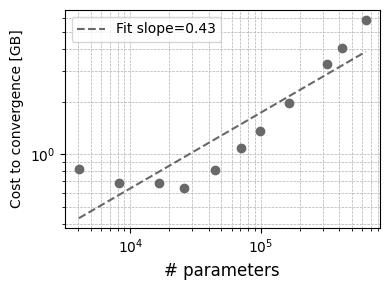

slope 0.36402453142003843
intercept -1.4162521501054777
NUms params : [4045, 8180, 16750, 25720, 44860, 71035, 99710, 164560, 324260, 419110, 638810]


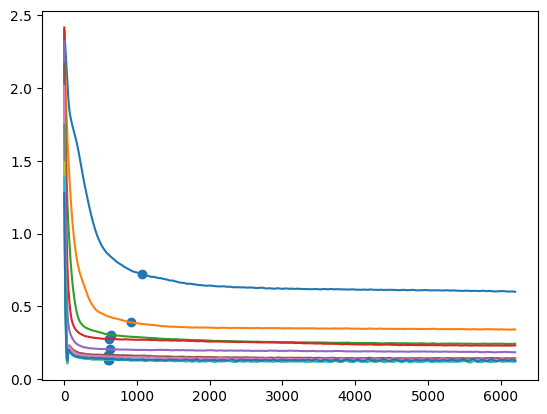

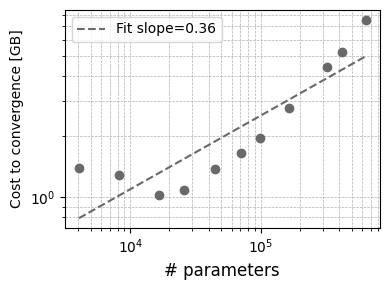

slope 0.24112593939719135
intercept -0.5055539354859091
NUms params : [4045, 8180, 16750, 25720, 44860, 71035, 99710, 164560, 324260, 419110, 638810]


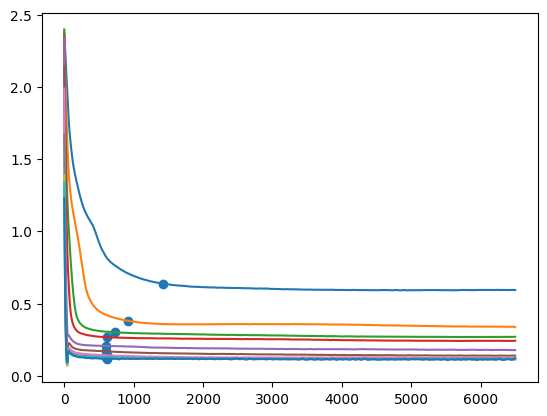

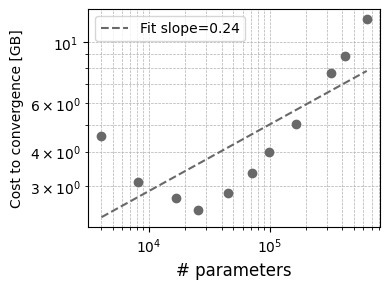

slope 0.20665104378521926
intercept -0.05754130135968098
NUms params : [4045, 8180, 16750, 25720, 44860, 71035, 99710, 164560, 324260, 419110, 638810]


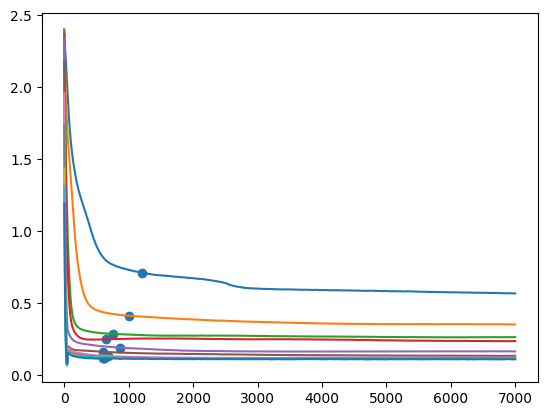

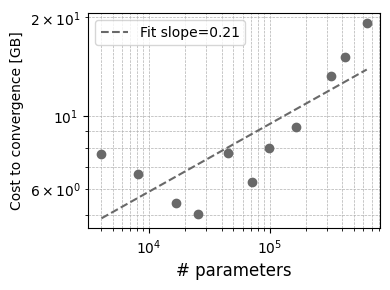

slope 0.17251374808521697
intercept 0.4109387522988898
NUms params : [4045, 8180, 16750, 25720, 44860, 71035, 99710, 164560, 324260, 419110, 638810]


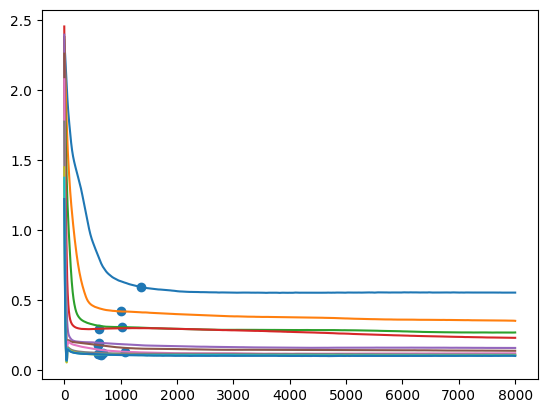

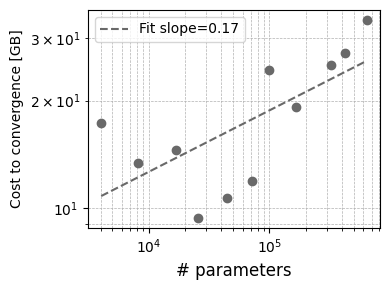

slope 0.09968216324335337
intercept 1.2213147700400289
NUms params : [4045, 8180, 16750, 25720, 44860, 71035, 99710, 164560, 324260, 419110, 638810]


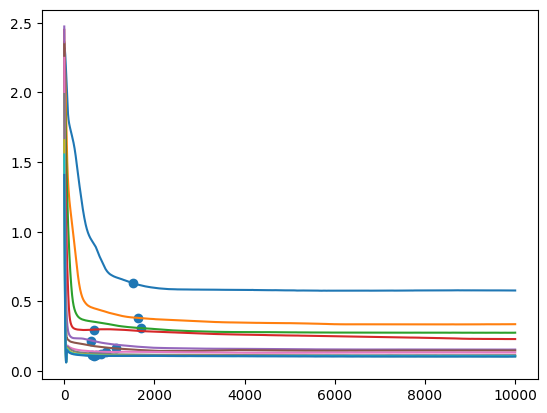

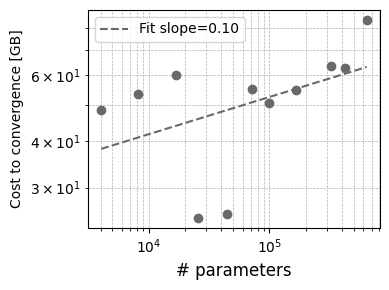

slope 0.13631760976409668
intercept 1.3539500265806799
NUms params : [4045, 8180, 16750, 25720, 44860, 71035, 99710, 164560, 324260, 419110, 638810]


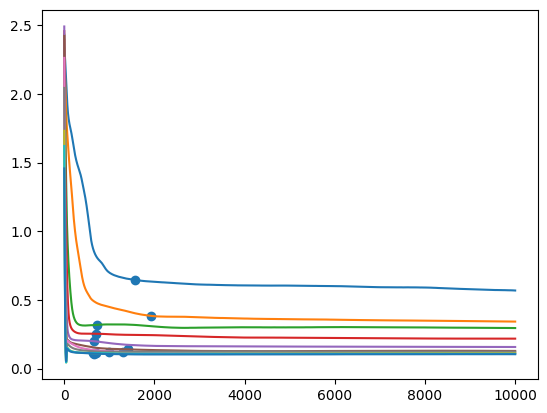

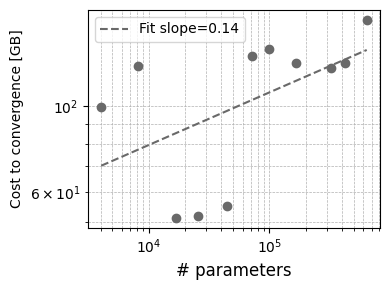

In [24]:
BP_mem_dict = {
    1:   BP_mem_perepoch_1,
    5:   BP_mem_perepoch_5,
    10:  BP_mem_perepoch_10,
    20:  BP_mem_perepoch_20,
    50:  BP_mem_perepoch_50,
    100: BP_mem_perepoch_100,
    200: BP_mem_perepoch_200,
    500: BP_mem_perepoch_500,
    1000: BP_mem_perepoch_1000,
    2000: BP_mem_perepoch_2000,
    5000: BP_mem_perepoch_5000,
    10000: BP_mem_perepoch_10000,
}

results_BP_batch = {}

for batch_size, mem_array in BP_mem_dict.items():

    filename = f'BP_batch_scan/paramscan_batch{batch_size}_PNN_BP_MNIST.pkl'

    with open(filename, 'rb') as f:
        avg_results_BP_batchsweep = pickle.load(f)
    knee_idx_BP_batch,loss_BP_batch,acc_BP_batch = locate_curve_knee(avg_results_BP_batchsweep,N_neurons_vec_BP,idx_start = 300,idx_run=-1,window_len=200,plot_bool=True)
    a, b, N_dim_vec_BP, BP_cost = process_cost_to_conv(avg_results_BP, knee_idx_BP_batch, mem_array)
    results_BP_batch[batch_size] = {
        "a": a,
        "b": b,
        "N_dim": N_dim_vec_BP,
        "cost": BP_cost,
        "knee_idx" : knee_idx_BP_batch,
        "test_loss" : loss_BP_batch,
        "test_acc" : acc_BP_batch
    }

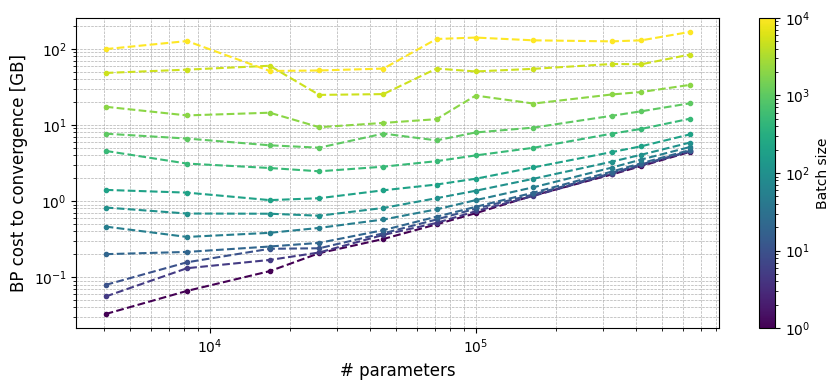

In [39]:

batch_sizes = sorted(results_BP_batch.keys())

plt.figure(figsize=(9, 4))
cmap = plt.cm.viridis
norm = mpl.colors.LogNorm(vmin=min(batch_sizes), vmax=max(batch_sizes))

for bs in batch_sizes:
    N_dim = results_BP_batch[bs]["N_dim"]
    cost  = results_BP_batch[bs]["cost"]
    plt.loglog(N_dim, cost,'--.', color=cmap(norm(bs)), label=f'Batch {bs}')

plt.xlabel(r'# parameters', fontsize=12)
plt.ylabel('BP cost to convergence [GB]', fontsize=12)
plt.grid(True, which="both", ls="--", lw=0.5)

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('Batch size')

plt.tight_layout()
plt.show()

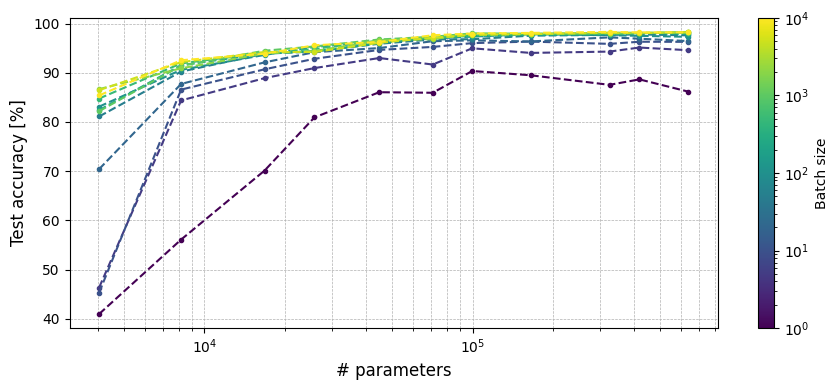

In [41]:

batch_sizes = sorted(results_BP_batch.keys())

plt.figure(figsize=(9, 4))
cmap = plt.cm.viridis
norm = mpl.colors.LogNorm(vmin=min(batch_sizes), vmax=max(batch_sizes))

for bs in batch_sizes:
    N_dim = results_BP_batch[bs]["N_dim"]
    cost  = results_BP_batch[bs]["test_acc"]
    plt.semilogx(N_dim, cost,'--.', color=cmap(norm(bs)), label=f'Batch {bs}')

plt.xlabel(r'# parameters', fontsize=12)
plt.ylabel('Test accuracy [%]', fontsize=12)
plt.grid(True, which="both", ls="--", lw=0.5)

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('Batch size')

plt.tight_layout()
plt.show()

BP loss-fit:    slope=-0.417, intercept=1.267
PEPG loss-fit:  slope=-0.755, intercept=3.075
SPSA loss-fit:  slope=-0.411, intercept=1.715


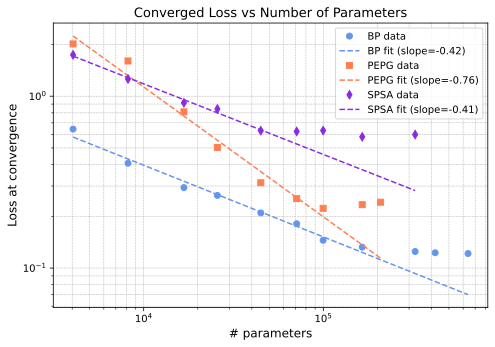

In [63]:
# ----- power-law fits (log-log) -----
a_BP_l,   b_BP_l   = np.polyfit(np.log10(N_dim_vec_BP[:-3]), np.log10(loss_BP_conv[:-3]),   1)
a_PEPG_l, b_PEPG_l = np.polyfit(np.log10(N_dim_vec_PEPG[:-2]), np.log10(loss_PEPG_conv[:-2]), 1)
a_SPSA_l, b_SPSA_l = np.polyfit(np.log10(N_dim_vec_SPSA[:-4]), np.log10(loss_SPSA_conv[:-4]), 1)

print(f"BP loss-fit:    slope={a_BP_l:.3f}, intercept={b_BP_l:.3f}")
print(f"PEPG loss-fit:  slope={a_PEPG_l:.3f}, intercept={b_PEPG_l:.3f}")
print(f"SPSA loss-fit:  slope={a_SPSA_l:.3f}, intercept={b_SPSA_l:.3f}")

# Predicted fits in original scale
fit_BP    = 10**(a_BP_l   * np.log10(N_dim_vec_BP) + b_BP_l)
fit_PEPG  = 10**(a_PEPG_l * np.log10(N_dim_vec_PEPG) + b_PEPG_l)
fit_SPSA  = 10**(a_SPSA_l * np.log10(N_dim_vec_SPSA) + b_SPSA_l)

# ----- plotting -----
plt.figure(figsize=(7,5))

# BP — cornflower blue
plt.loglog(N_dim_vec_BP, loss_BP_conv, 'o', color='cornflowerblue', label='BP data')
plt.loglog(N_dim_vec_BP, fit_BP, '--',  color='cornflowerblue', label=f'BP fit (slope={a_BP_l:.2f})')

# PEPG — coral
plt.loglog(N_dim_vec_PEPG, loss_PEPG_conv, 's', color='coral', label='PEPG data')
plt.loglog(N_dim_vec_PEPG, fit_PEPG, '--',  color='coral', label=f'PEPG fit (slope={a_PEPG_l:.2f})')

# SPSA — blueviolet
plt.loglog(N_dim_vec_SPSA, loss_SPSA_conv, 'd', color='blueviolet', label='SPSA data')
plt.loglog(N_dim_vec_SPSA, fit_SPSA, '--',  color='blueviolet', label=f'SPSA fit (slope={a_SPSA_l:.2f})')

plt.xlabel(r'# parameters', fontsize=12)
plt.ylabel('Loss at convergence', fontsize=12)
plt.title('Converged Loss vs Number of Parameters', fontsize=13)
plt.legend()
plt.grid(True, which="both", ls="--", lw=0.5)
plt.tight_layout()
plt.show()

BP loss-fit:    slope=-0.417, intercept=1.267
PEPG loss-fit:  slope=-0.755, intercept=3.075
SPSA loss-fit:  slope=-0.411, intercept=1.715


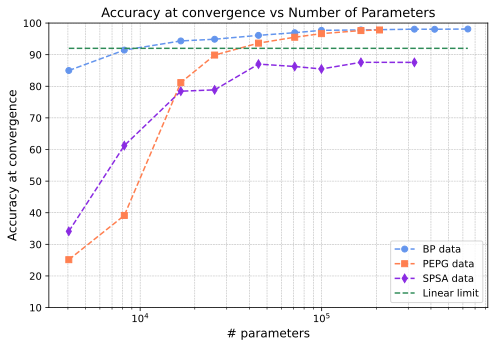

In [64]:

print(f"BP loss-fit:    slope={a_BP_l:.3f}, intercept={b_BP_l:.3f}")
print(f"PEPG loss-fit:  slope={a_PEPG_l:.3f}, intercept={b_PEPG_l:.3f}")
print(f"SPSA loss-fit:  slope={a_SPSA_l:.3f}, intercept={b_SPSA_l:.3f}")

# Predicted fits in original scale
fit_BP    = 10**(a_BP_l   * np.log10(N_dim_vec_BP) + b_BP_l)
fit_PEPG  = 10**(a_PEPG_l * np.log10(N_dim_vec_PEPG) + b_PEPG_l)
fit_SPSA  = 10**(a_SPSA_l * np.log10(N_dim_vec_SPSA) + b_SPSA_l)

# ----- plotting -----
plt.figure(figsize=(7,5))

# BP — cornflower blue
plt.semilogx(N_dim_vec_BP, acc_BP_conv, '--o', color='cornflowerblue', label='BP data')

# PEPG — coral
plt.semilogx(N_dim_vec_PEPG, acc_PEPG_conv, '--s', color='coral', label='PEPG data')

# SPSA — blueviolet
plt.semilogx(N_dim_vec_SPSA, acc_SPSA_conv, '--d', color='blueviolet', label='SPSA data')

#linear classifier
# linear limit
plt.semilogx(N_dim_vec_BP, np.ones(len(N_dim_vec_BP))*92, '--', color='seagreen', label='Linear limit')

plt.xlabel(r'# parameters', fontsize=12)
plt.ylabel('Accuracy at convergence', fontsize=12)
plt.title('Accuracy at convergence vs Number of Parameters', fontsize=13)
plt.ylim([10,100])
plt.legend()
plt.grid(True, which="both", ls="--", lw=0.5)
plt.tight_layout()
plt.show()

BP:    slope=-0.116, intercept=1.702
PEPG:  slope=1.539, intercept=-4.226
SPSA:  slope=0.994, intercept=-2.826


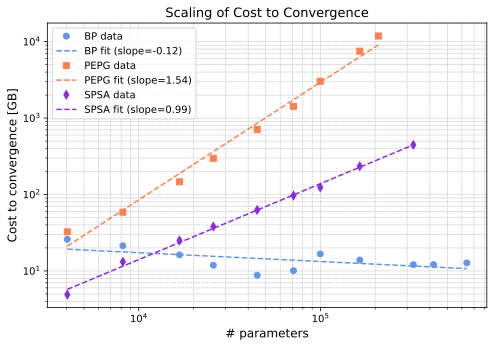

In [65]:
# Fit lines (log-log)
a_BP, b_BP = np.polyfit(np.log10(N_dim_vec_BP), np.log10(BP_cost_to_conv), 1)
a_PEPG, b_PEPG = np.polyfit(np.log10(N_dim_vec_PEPG), np.log10(PEPG_cost_to_conv), 1)
a_SPSA, b_SPSA = np.polyfit(np.log10(N_dim_vec_SPSA), np.log10(SPSA_cost_to_conv), 1)




# Print slopes and intercepts
print(f"BP:    slope={a_BP:.3f}, intercept={b_BP:.3f}")
print(f"PEPG:  slope={a_PEPG:.3f}, intercept={b_PEPG:.3f}")
print(f"SPSA:  slope={a_SPSA:.3f}, intercept={b_SPSA:.3f}")

# Plot data and fits
plt.figure(figsize=(7,5))

# BP - black
plt.loglog(N_dim_vec_BP, BP_cost_to_conv, 'o', color='cornflowerblue', label='BP data')
plt.loglog(N_dim_vec_BP, 10**(a_BP*np.log10(N_dim_vec_BP) + b_BP), '--', color='cornflowerblue', label=f'BP fit (slope={a_BP:.2f})')

# PEPG - orange
plt.loglog(N_dim_vec_PEPG, PEPG_cost_to_conv, 's', color='coral', label='PEPG data')
plt.loglog(N_dim_vec_PEPG, 10**(a_PEPG*np.log10(N_dim_vec_PEPG) + b_PEPG), '--', color='coral', label=f'PEPG fit (slope={a_PEPG:.2f})')

# SPSA - purple
plt.loglog(N_dim_vec_SPSA, SPSA_cost_to_conv, 'd', color='blueviolet', label='SPSA data')
plt.loglog(N_dim_vec_SPSA, 10**(a_SPSA*np.log10(N_dim_vec_SPSA) + b_SPSA), '--', color='blueviolet', label=f'SPSA fit (slope={a_SPSA:.2f})')


# Labels and style
plt.xlabel(r'# parameters', fontsize=12)
plt.ylabel('Cost to convergence [GB]', fontsize=12)
plt.title('Scaling of Cost to Convergence', fontsize=13)
plt.legend()
plt.grid(True, which="both", ls="--", lw=0.5)
plt.tight_layout()
plt.show()

BP:    slope=-0.685, intercept=-0.097
PEPG:  slope=-0.582, intercept=1.188
SPSA:  slope=-0.392, intercept=0.522


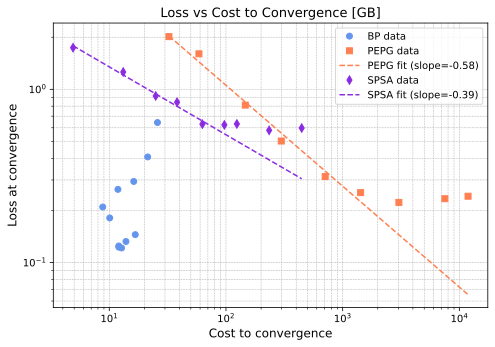

In [78]:
# Fit lines (log-log)
a_BP, b_BP = np.polyfit(np.log10(BP_cost_to_conv[4:]),   np.log10(loss_BP_conv[4:]),   1)
a_PEPG, b_PEPG = np.polyfit(np.log10(PEPG_cost_to_conv[:-3]), np.log10(loss_PEPG_conv[:-3]), 1)
a_SPSA, b_SPSA = np.polyfit(np.log10(SPSA_cost_to_conv[:-4]), np.log10(loss_SPSA_conv[:-4]), 1)

# Print slopes and intercepts
print(f"BP:    slope={a_BP:.3f}, intercept={b_BP:.3f}")
print(f"PEPG:  slope={a_PEPG:.3f}, intercept={b_PEPG:.3f}")
print(f"SPSA:  slope={a_SPSA:.3f}, intercept={b_SPSA:.3f}")

# Plot data and fits
plt.figure(figsize=(7,5))

# BP — cornflower blue
plt.loglog(BP_cost_to_conv, loss_BP_conv, 'o', color='cornflowerblue', label='BP data')
#plt.loglog(BP_cost_to_conv, 10**(a_BP*np.log10(BP_cost_to_conv) + b_BP), '--', color='cornflowerblue', label=f'BP fit (slope={a_BP:.2f})')

# PEPG — coral
plt.loglog(PEPG_cost_to_conv, loss_PEPG_conv, 's', color='coral', label='PEPG data')
plt.loglog(PEPG_cost_to_conv, 10**(a_PEPG*np.log10(PEPG_cost_to_conv) + b_PEPG), '--', color='coral', label=f'PEPG fit (slope={a_PEPG:.2f})')

# SPSA — blueviolet
plt.loglog(SPSA_cost_to_conv, loss_SPSA_conv, 'd', color='blueviolet', label='SPSA data')
plt.loglog(SPSA_cost_to_conv, 10**(a_SPSA*np.log10(SPSA_cost_to_conv) + b_SPSA), '--', color='blueviolet', label=f'SPSA fit (slope={a_SPSA:.2f})')

# Labels and styling
plt.xlabel('Cost to convergence', fontsize=12)
plt.ylabel('Loss at convergence', fontsize=12)
plt.title('Loss vs Cost to Convergence [GB]', fontsize=13)
plt.legend()
plt.grid(True, which="both", ls="--", lw=0.5)
plt.tight_layout()
plt.show()#

In [37]:
results_BP_batch[20]

{'a': np.float64(0.6676547499766838),
 'b': np.float64(-3.342374694745683),
 'N_dim': [4045,
  8180,
  16750,
  25720,
  44860,
  71035,
  99710,
  164560,
  324260,
  419110,
  638810],
 'cost': array([0.20068 , 0.21465 , 0.252984, 0.282384, 0.41541 , 0.623484,
        0.8401  , 1.291626, 2.441262, 3.146958, 4.687199]),
 'knee_idx': array([1160,  954,  762,  636,  610,  621,  620,  603,  601,  606,  601]),
 'test_loss': array([0.95106334, 0.53660812, 0.35931497, 0.27371169, 0.23186279,
        0.20163462, 0.18735742, 0.18855087, 0.19202124, 0.19709538,
        0.21346682]),
 'test_acc': array([70.42, 87.73, 92.12, 94.19, 95.03, 96.42, 96.59, 96.37, 97.2 ,
        96.93, 96.44])}

In [27]:
acc_PEPG_conv

array([25.15      , 39.14      , 81.16333333, 89.87333333, 93.64666667,
       95.51333333, 96.65      , 97.62      , 97.80666667])

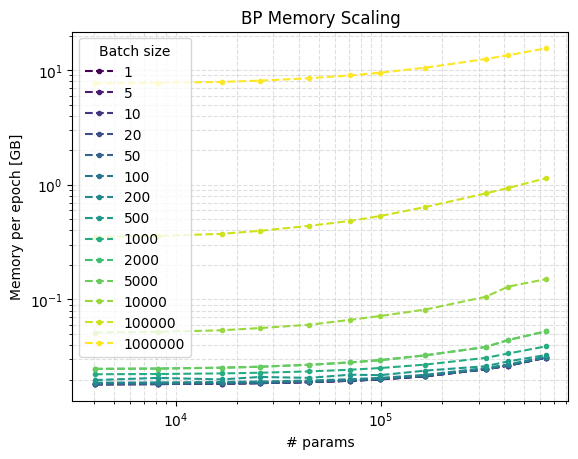

In [16]:
#with measured load from CUDA torch instead of theory

BP_mem_perepoch_1 = np.array([18.19, 18.269, 18.443, 18.622, 19.001, 19.521, 20.097, 21.395, 24.587, 26.489, 31.049])/1000 
BP_mem_perepoch_5 = np.array([18.202, 18.281, 18.456, 18.635, 19.014, 19.533, 20.109, 21.407, 24.6, 26.502, 31.061])/1000
BP_mem_perepoch_10 = np.array([18.218, 18.297, 18.471, 18.651, 19.03, 19.549, 20.125, 21.423, 24.615, 26.518, 31.077])/1000 
BP_mem_perepoch_20 = np.array([18.249, 18.329, 18.503, 18.682, 19.061, 19.58, 20.156, 21.454, 24.647, 26.549, 31.108])/1000 
BP_mem_perepoch_50 = np.array([18.343, 18.423, 18.597, 18.776, 19.155, 19.675, 20.251, 21.549, 24.741, 26.643, 31.202])/1000 
BP_mem_perepoch_100 = np.array([18.501, 18.58, 18.754, 18.933, 19.312, 19.832, 20.408, 21.706, 24.898, 26.8, 31.359])/1000
BP_mem_perepoch_200 = np.array([18.815, 18.894, 19.068, 19.248, 19.626, 20.146, 20.722, 22.02, 25.212, 27.114, 31.674])/1000 

BP_mem_perepoch_500 = np.array([19.812, 20.686, 20.076, 21.079, 20.711, 22.068, 21.87, 23.945, 26.156, 28.853, 32.762])/1000 
BP_mem_perepoch_1000 = np.array([22.27, 22.378, 22.643, 22.951, 23.578, 24.39, 25.239, 27.018, 30.939, 33.817, 38.973])/1000
BP_mem_perepoch_2000 = np.array([24.798, 24.966, 25.391, 25.898, 26.927, 28.238, 29.586, 32.545, 38.466, 44.307, 52.754])/1000

BP_mem_perepoch_5000 = np.array([24.798, 24.966, 25.391, 25.898, 26.927, 28.238, 29.586, 32.545, 38.466, 44.307, 52.754])/1000 
BP_mem_perepoch_10000 = np.array([51.487, 52.135, 53.84, 56.279, 60.176, 66.421, 71.805, 81.615, 105.478, 129.487, 150.402])/1000 
BP_mem_perepoch_100000 = np.array([351.973, 358.021, 373.674, 396.697, 438.867, 484.323, 534.669, 639.537, 840.686, 938.513, 1141.897])/1000 
BP_mem_perepoch_1000000 = np.array([7681.618, 7741.665, 7901.772, 8101.879, 8502.107, 9002.421, 9504.99, 10503.547, 12507.174, 13506.61, 15511.27])/1000 

#  y-data arrays in a list (in the same order as plot )
BP_arrays = [
    BP_mem_perepoch_1,
    BP_mem_perepoch_5,
    BP_mem_perepoch_10,
    BP_mem_perepoch_20,
    BP_mem_perepoch_50,
    BP_mem_perepoch_100,
    BP_mem_perepoch_200,
    BP_mem_perepoch_500,
    BP_mem_perepoch_1000,
    BP_mem_perepoch_2000,
    BP_mem_perepoch_5000,
    BP_mem_perepoch_10000,
    BP_mem_perepoch_100000,
    BP_mem_perepoch_1000000
]

# The labels for the legend
labels = ["1", "5", "10", "20", "50", "100","200", "500", "1000","2000","5000","10000","100000","1000000"]

# Build a colormap proportional to number of curves
cmap = plt.cm.viridis
colors = cmap(np.linspace(0, 1, len(BP_arrays)))

a_BP_batchsweep = []
b_BP_batchsweep = []
plt.figure()
for arr, label, color in zip(BP_arrays, labels, colors):
    plt.loglog(N_dim_vec_BP, arr, '--.', color=color, label=label)
    a_BP, b_BP = np.polyfit(np.log10(N_dim_vec_BP[-5:]), np.log10(arr[-5:]), 1)  # linear fit
    a_BP_batchsweep.append(a_BP)
    b_BP_batchsweep.append(b_BP)
    

# Legend depending on number
plt.legend(title="Batch size", fontsize=10)

plt.xlabel("# params")
plt.ylabel("Memory per epoch [GB]")
plt.title("BP Memory Scaling")
plt.grid(True, which="both", ls="--", alpha=0.4)

plt.show()


Text(0, 0.5, 'Asymptote slope')

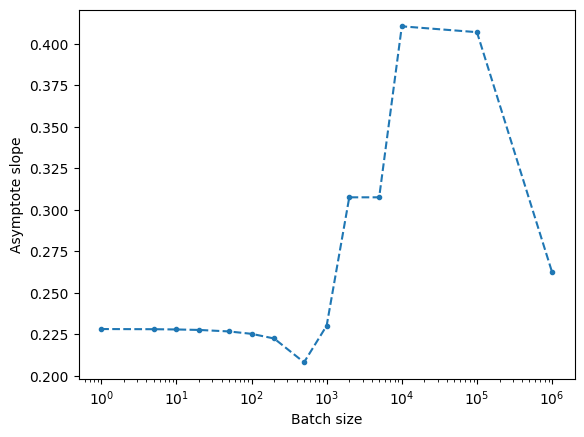

In [17]:
labels = [int(i) for i in labels]
plt.semilogx(labels,a_BP_batchsweep,'.--')
plt.xlabel("Batch size")
plt.ylabel("Asymptote slope")